# Model Evaluation Notebook

This notebook evaluates both pretrained and fine-tuned models on the test dataset.
Compares performance between base model and fine-tuned version.


In [1]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
from peft import PeftModel
import warnings
warnings.filterwarnings('ignore')


## Configuration


In [10]:
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
FINETUNED_PATH = "./intent_classification/checkpoint-10064"
DATASET_NAME = "codefactory4791/amazon_test"
SPLIT = "test"
BATCH_SIZE = 32

print(f"Base Model: {BASE_MODEL}")
print(f"Fine-tuned Model Path: {FINETUNED_PATH}")
print(f"Dataset: {DATASET_NAME}")
print(f"Split: {SPLIT}")
print(f"Batch Size: {BATCH_SIZE}")


Base Model: Qwen/Qwen2.5-0.5B-Instruct
Fine-tuned Model Path: ./intent_classification/checkpoint-10064
Dataset: codefactory4791/amazon_test
Split: test
Batch Size: 32


## Load Dataset


In [3]:
def load_eval_dataset(dataset_name, split="test"):
    print("="*70)
    print(f"Loading Dataset: {dataset_name}")
    print("="*70)
    print(f"Split: {split}")
    
    dataset = load_dataset(dataset_name)
    eval_df = dataset[split].to_pandas()
    
    # Rename columns if needed
    if 'query' in eval_df.columns and 'label' in eval_df.columns:
        eval_df = eval_df.rename(columns={'query': 'text', 'label': 'labels'})
    
    # Create label mappings
    labels = sorted(eval_df['labels'].unique())
    label2id = {lbl: idx for idx, lbl in enumerate(labels)}
    id2label = {idx: lbl for idx, lbl in enumerate(labels)}
    
    eval_df['label_id'] = eval_df['labels'].map(label2id)
    
    print(f"Samples: {len(eval_df):,}")
    print(f"Number of classes: {len(labels)}")
    
    return eval_df, labels, label2id, id2label

eval_df, labels, label2id, id2label = load_eval_dataset(DATASET_NAME, SPLIT)


Loading Dataset: codefactory4791/amazon_test
Split: test
Samples: 10,350
Number of classes: 23


In [4]:
eval_df.head()


,text,labels,label_id
0,Beautiful design. Twelve rolls of the most bea...,arts-crafts-and-sewing_crafting,0
1,Gluten Free Lip Balm - Buy These - Your Lips W...,arts-crafts-and-sewing_crafting,0
2,Yarn cakes for dinner. I carefully compared ba...,arts-crafts-and-sewing_crafting,0
3,Perfectly moldable and doesn't burn my fingers...,arts-crafts-and-sewing_crafting,0
4,Highly impressed. This is an incredibly nice s...,arts-crafts-and-sewing_crafting,0


## Load Base Model


In [5]:
def load_base_model(model_name, num_labels, label2id, id2label):
    print("\n" + "="*70)
    print("Loading Base Model")
    print("="*70)
    print(f"Model: {model_name}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    model.config.pad_token_id = tokenizer.pad_token_id
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    print(f"Device: {device}")
    print(f"Model loaded successfully")
    
    return model, tokenizer, device

base_model, base_tokenizer, device = load_base_model(
    BASE_MODEL,
    len(labels),
    label2id,
    id2label
)



Loading Base Model
Model: Qwen/Qwen2.5-0.5B-Instruct


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Model loaded successfully


## Evaluation Function


In [63]:
from tqdm import tqdm

def evaluate_model(model, tokenizer, eval_df, id2label, batch_size=32, model_name="Model"):
    print("\n" + "="*70)
    print(f"Evaluating {model_name}")
    print("="*70)
    
    device = next(model.parameters()).device
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    texts = eval_df['text'].tolist()
    labels = eval_df['label_id'].tolist()
    
    print(f"Running inference on {len(texts):,} samples...")
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            )
            
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            probs = torch.softmax(logits, dim=-1)
            predictions = torch.argmax(logits, dim=-1).cpu().numpy()
            
            all_predictions.extend(predictions)
            all_labels.extend(batch_labels)
            all_probabilities.extend(probs.cpu().numpy())
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"  Processed {i + len(batch_texts):,} / {len(texts):,} samples")
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    accuracy = accuracy_score(all_labels, all_predictions)
    balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
    f1_macro = f1_score(all_labels, all_predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
    precision_macro = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    recall_macro = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    
    print("\n" + "="*70)
    print(f"{model_name} - Results")
    print("="*70)
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Balanced Accuracy:  {balanced_acc:.4f}")
    print(f"F1 Score (Macro):   {f1_macro:.4f}")
    print(f"F1 Score (Weighted):{f1_weighted:.4f}")
    print(f"Precision (Macro):  {precision_macro:.4f}")
    print(f"Recall (Macro):     {recall_macro:.4f}")
    
    print("\n" + "="*70)
    print(f"{model_name} - Classification Report")
    print("="*70)
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=[id2label[i] for i in sorted(id2label.keys())],
        digits=4,
        zero_division=0
    ))
    
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }


## Evaluate Base Model


In [7]:
base_results = evaluate_model(
    base_model,
    base_tokenizer,
    eval_df,
    id2label,
    BATCH_SIZE,
    model_name="Base Model"
)



Evaluating Base Model
Running inference on 10,350 samples...
  Processed 320 / 10,350 samples
  Processed 640 / 10,350 samples
  Processed 960 / 10,350 samples
  Processed 1,280 / 10,350 samples
  Processed 1,600 / 10,350 samples
  Processed 1,920 / 10,350 samples
  Processed 2,240 / 10,350 samples
  Processed 2,560 / 10,350 samples
  Processed 2,880 / 10,350 samples
  Processed 3,200 / 10,350 samples
  Processed 3,520 / 10,350 samples
  Processed 3,840 / 10,350 samples
  Processed 4,160 / 10,350 samples
  Processed 4,480 / 10,350 samples
  Processed 4,800 / 10,350 samples
  Processed 5,120 / 10,350 samples
  Processed 5,440 / 10,350 samples
  Processed 5,760 / 10,350 samples
  Processed 6,080 / 10,350 samples
  Processed 6,400 / 10,350 samples
  Processed 6,720 / 10,350 samples
  Processed 7,040 / 10,350 samples
  Processed 7,360 / 10,350 samples
  Processed 7,680 / 10,350 samples
  Processed 8,000 / 10,350 samples
  Processed 8,320 / 10,350 samples
  Processed 8,640 / 10,350 samples

## Free Memory


In [8]:
del base_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Base model memory freed")


Base model memory freed


## Load Fine-tuned Model


In [11]:
def load_finetuned_model(finetuned_path, base_model_name, num_labels, label2id, id2label):
    print("\n" + "="*70)
    print("Loading Fine-tuned Model")
    print("="*70)
    print(f"Fine-tuned path: {finetuned_path}")
    print(f"Base model: {base_model_name}")
    
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, add_prefix_space=True)
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.pad_token = tokenizer.eos_token
    
    base_model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    model = PeftModel.from_pretrained(base_model, finetuned_path)
    model = model.merge_and_unload()
    
    model.config.pad_token_id = tokenizer.pad_token_id
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    print(f"Device: {device}")
    print(f"Fine-tuned model loaded successfully")
    
    return model, tokenizer, device

finetuned_model, finetuned_tokenizer, device = load_finetuned_model(
    FINETUNED_PATH,
    BASE_MODEL,
    len(labels),
    label2id,
    id2label
)



Loading Fine-tuned Model
Fine-tuned path: ./intent_classification/checkpoint-10064
Base model: Qwen/Qwen2.5-0.5B-Instruct


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Fine-tuned model loaded successfully


## Evaluate Fine-tuned Model


In [12]:
finetuned_results = evaluate_model(
    finetuned_model,
    finetuned_tokenizer,
    eval_df,
    id2label,
    BATCH_SIZE,
    model_name="Fine-tuned Model"
)



Evaluating Fine-tuned Model
Running inference on 10,350 samples...
  Processed 320 / 10,350 samples
  Processed 640 / 10,350 samples
  Processed 960 / 10,350 samples
  Processed 1,280 / 10,350 samples
  Processed 1,600 / 10,350 samples
  Processed 1,920 / 10,350 samples
  Processed 2,240 / 10,350 samples
  Processed 2,560 / 10,350 samples
  Processed 2,880 / 10,350 samples
  Processed 3,200 / 10,350 samples
  Processed 3,520 / 10,350 samples
  Processed 3,840 / 10,350 samples
  Processed 4,160 / 10,350 samples
  Processed 4,480 / 10,350 samples
  Processed 4,800 / 10,350 samples
  Processed 5,120 / 10,350 samples
  Processed 5,440 / 10,350 samples
  Processed 5,760 / 10,350 samples
  Processed 6,080 / 10,350 samples
  Processed 6,400 / 10,350 samples
  Processed 6,720 / 10,350 samples
  Processed 7,040 / 10,350 samples
  Processed 7,360 / 10,350 samples
  Processed 7,680 / 10,350 samples
  Processed 8,000 / 10,350 samples
  Processed 8,320 / 10,350 samples
  Processed 8,640 / 10,350 s

## Compare Models


In [13]:
def compare_models(base_results, finetuned_results):
    print("\n" + "="*70)
    print("Model Comparison")
    print("="*70)
    
    metrics = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']
    
    print(f"\n{'Metric':<25} {'Base Model':<15} {'Fine-tuned':<15} {'Improvement':<15}")
    print("-" * 70)
    
    comparison_data = []
    
    for metric in metrics:
        base_val = base_results[metric]
        ft_val = finetuned_results[metric]
        improvement = ft_val - base_val
        improvement_pct = (improvement / base_val * 100) if base_val > 0 else 0
        
        print(f"{metric.replace('_', ' ').title():<25} {base_val:<15.4f} {ft_val:<15.4f} {improvement:>+.4f} ({improvement_pct:>+.2f}%)")
        
        comparison_data.append({
            'Metric': metric.replace('_', ' ').title(),
            'Base Model': base_val,
            'Fine-tuned': ft_val,
            'Improvement': improvement,
            'Improvement %': improvement_pct
        })
    
    print("="*70)
    
    return pd.DataFrame(comparison_data)

comparison_df = compare_models(base_results, finetuned_results)



Model Comparison

Metric                    Base Model      Fine-tuned      Improvement    
----------------------------------------------------------------------
Accuracy                  0.0384          0.9207          +0.8823 (+2300.25%)
Balanced Accuracy         0.0384          0.9207          +0.8823 (+2300.25%)
F1 Macro                  0.0184          0.9207          +0.9023 (+4893.26%)
F1 Weighted               0.0184          0.9207          +0.9023 (+4893.26%)
Precision Macro           0.0354          0.9209          +0.8855 (+2504.94%)
Recall Macro              0.0384          0.9207          +0.8823 (+2300.25%)


In [14]:
comparison_df


,Metric,Base Model,Fine-tuned,Improvement,Improvement %
0,Accuracy,0.038357,0.920676,0.882319,2300.251889
1,Balanced Accuracy,0.038357,0.920676,0.882319,2300.251889
2,F1 Macro,0.018439,0.920720,0.902281,4893.257777
3,F1 Weighted,0.018439,0.920720,0.902281,4893.257777
4,Precision Macro,0.035351,0.920879,0.885528,2504.944471
5,Recall Macro,0.038357,0.920676,0.882319,2300.251889


## Visualize Comparison


In [18]:
# !pip install matplotlib

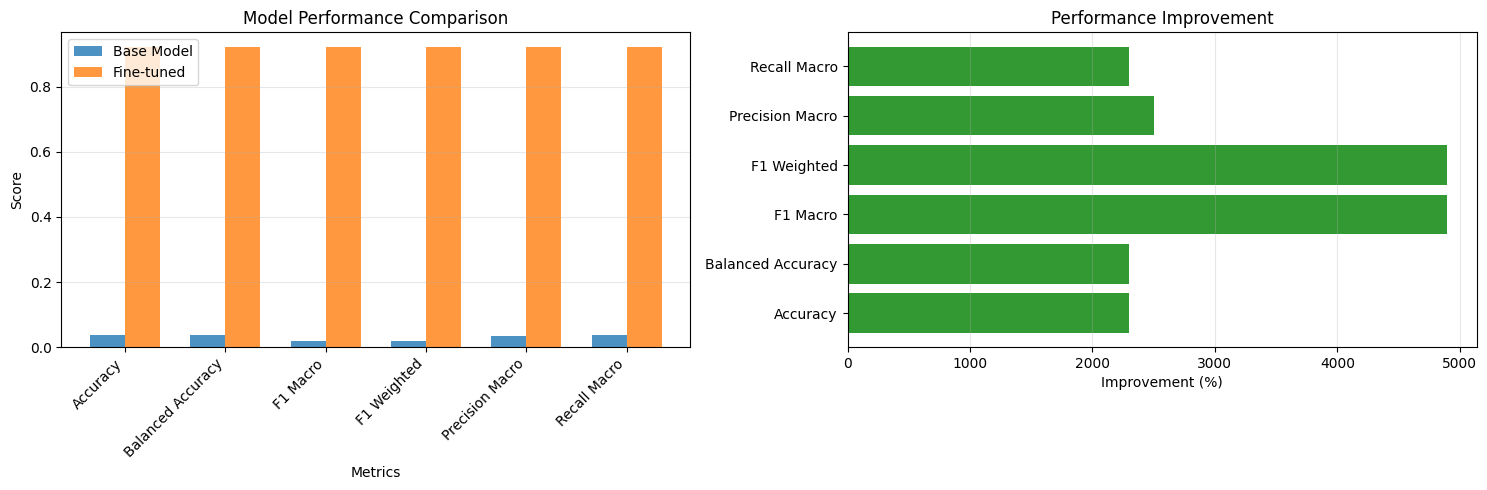

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics = comparison_df['Metric']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Base Model'], width, label='Base Model', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['Fine-tuned'], width, label='Fine-tuned', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].barh(metrics, comparison_df['Improvement %'], alpha=0.8, color='green')
axes[1].set_xlabel('Improvement (%)')
axes[1].set_title('Performance Improvement')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Confusion Matrix


In [20]:
!pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


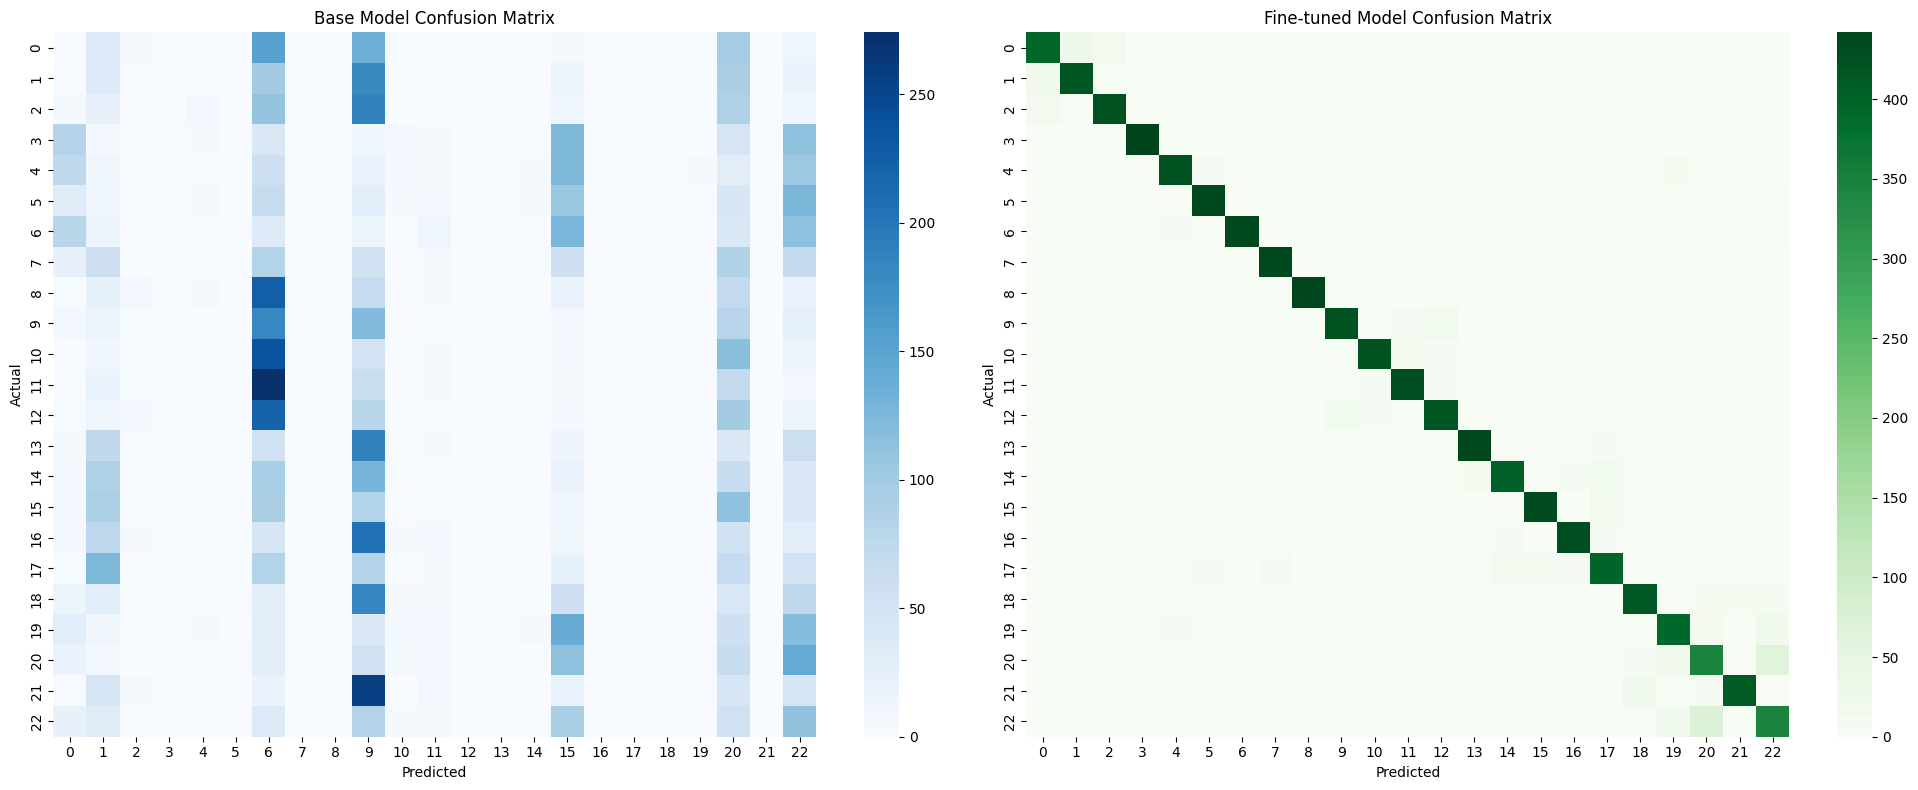

In [21]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_base = confusion_matrix(base_results['labels'], base_results['predictions'])
sns.heatmap(cm_base, annot=False, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Base Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_finetuned = confusion_matrix(finetuned_results['labels'], finetuned_results['predictions'])
sns.heatmap(cm_finetuned, annot=False, fmt='d', cmap='Greens', ax=axes[1], cbar=True)
axes[1].set_title('Fine-tuned Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Summary


In [22]:
print("="*70)
print("Evaluation Complete")
print("="*70)
print(f"\nDataset: {DATASET_NAME}")
print(f"Split: {SPLIT}")
print(f"Samples evaluated: {len(eval_df):,}")
print(f"\nBase Model Accuracy: {base_results['accuracy']:.4f}")
print(f"Fine-tuned Model Accuracy: {finetuned_results['accuracy']:.4f}")
print(f"Improvement: {(finetuned_results['accuracy'] - base_results['accuracy']):.4f}")
print("="*70)


Evaluation Complete

Dataset: codefactory4791/amazon_test
Split: test
Samples evaluated: 10,350

Base Model Accuracy: 0.0384
Fine-tuned Model Accuracy: 0.9207
Improvement: 0.8823


# Pushing Model to Hub

In [23]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
from huggingface_hub import notebook_login

In [24]:
# Step 1: authenticate to the Hub
notebook_login() 

In [27]:
# Step 2: load your base model and apply the LoRA adapter
base_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
num_labels = len(labels) # e.g. 25 for Amazon5x5
base_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=num_labels,
    trust_remote_code=True,
    ignore_mismatched_sizes=True
)

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Load the LoRA adapter (trained earlier)
lora_checkpoint = "./intent_classification/checkpoint-10064"
model_with_adapter = PeftModel.from_pretrained(base_model, lora_checkpoint)

# Merge the LoRA weights into the base model
merged_model = model_with_adapter.merge_and_unload()


# # Step 3: push the merged model and tokenizer to your repository on the Hub

from transformers import AutoTokenizer
from huggingface_hub import login, create_repo
# Assume merged_model is your model after merge_and_unload()

# 1. Log in with a token that has write permissions
huggingface_token = ''
login(token=huggingface_token)  # or notebook_login()

# 2. Define the repository under your user or org name
repo_id = "codefactory4791/intent-classification-qwen"

# 3. Create the repo if it doesn't exist (set private=True if desired)
create_repo(repo_id, private=True, exist_ok=True)

# 4. Push the model and tokenizer to the Hub
merged_model.push_to_hub(repo_id)      # upload weights & config
tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.push_to_hub(repo_id)



Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/codefactory4791/intent-classification-qwen/commit/ac7365616d9d2edc8c83178144276f2a4fc330f4', commit_message='Upload tokenizer', commit_description='', oid='ac7365616d9d2edc8c83178144276f2a4fc330f4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/codefactory4791/intent-classification-qwen', endpoint='https://huggingface.co', repo_type='model', repo_id='codefactory4791/intent-classification-qwen'), pr_revision=None, pr_num=None)

# Testing Uploaded Model for Inference

This is the inference code, work from here to speed up inference

In [48]:
DATASET_NAME= 'codefactory4791/amazon_test'
SPLIT = 'test'
test_df, labels, label2id, id2label = load_eval_dataset(DATASET_NAME, SPLIT)

Loading Dataset: codefactory4791/amazon_test
Split: test
Samples: 10,350
Number of classes: 23


In [60]:
test_df = test_df.sample(1000) # selecting just 1000 samples for now

In [61]:
test_df.shape

(1000, 3)

In [55]:
# Option 2: load model and tokenizer manually and inspect logits / labels
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


model_id = "codefactory4791/intent-classification-qwen"

# load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

# Fix the missing pad_token: set it to eos_token if not defined
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# ensure the model knows which token is the pad token
model.config.pad_token_id = tokenizer.pad_token_id

In [51]:
id2label

{0: 'arts-crafts-and-sewing_crafting',
 1: 'arts-crafts-and-sewing_painting-drawing-art-print',
 2: 'arts-crafts-and-sewing_sewing',
 3: 'electronics_camera-photo',
 4: 'electronics_computers-accessories',
 5: 'electronics_headphones',
 6: 'electronics_television-video',
 7: 'electronics_vehicle-electronics',
 8: 'grocery-and-gourmet-food_beverages',
 9: 'grocery-and-gourmet-food_candy',
 10: 'grocery-and-gourmet-food_cooking-baking',
 11: 'grocery-and-gourmet-food_herbs-spices-seasonings',
 12: 'grocery-and-gourmet-food_snack-foods',
 13: 'musical-instruments_guitars',
 14: 'musical-instruments_instrument-accessories',
 15: 'musical-instruments_microphones',
 16: 'musical-instruments_other-instruments',
 17: 'musical-instruments_studio-recording',
 18: 'video-games_nintendo',
 19: 'video-games_pc',
 20: 'video-games_playstation',
 21: 'video-games_retro-gaming-microconsoles',
 22: 'video-games_xbox'}

In [64]:
BATCH_SIZE = 32
sample_results = evaluate_model(
    model,
    tokenizer,
    test_df,
    id2label,
    BATCH_SIZE,
    model_name="Fine-tuned Model"
)


Evaluating Fine-tuned Model
Running inference on 1,000 samples...


 31%|███▏      | 10/32 [03:52<08:25, 22.99s/it]

  Processed 320 / 1,000 samples


 62%|██████▎   | 20/32 [07:56<05:05, 25.45s/it]

  Processed 640 / 1,000 samples


 94%|█████████▍| 30/32 [12:13<00:49, 24.89s/it]

  Processed 960 / 1,000 samples


100%|██████████| 32/32 [12:44<00:00, 23.90s/it]


Fine-tuned Model - Results
Accuracy:           0.9200
Balanced Accuracy:  0.9214
F1 Score (Macro):   0.9199
F1 Score (Weighted):0.9195
Precision (Macro):  0.9198
Recall (Macro):     0.9214

Fine-tuned Model - Classification Report
                                                   precision    recall  f1-score   support

                  arts-crafts-and-sewing_crafting     0.9512    0.8667    0.9070        45
arts-crafts-and-sewing_painting-drawing-art-print     0.9556    0.9773    0.9663        44
                    arts-crafts-and-sewing_sewing     0.9512    0.9512    0.9512        41
                         electronics_camera-photo     0.9778    0.9565    0.9670        46
                electronics_computers-accessories     0.9024    0.9487    0.9250        39
                           electronics_headphones     0.9535    0.9535    0.9535        43
                     electronics_television-video     0.9808    0.9623    0.9714        53
                  electronics_vehicle-e

In [ ]:
sample_results